# 🎯 K-Means Clustering — Theory, From-Scratch Implementation & Scikit-Learn

## 📘 Topic: Unsupervised Learning — K-Means Clustering

### 🎓 Learning Objectives
By the end of this notebook, you will be able to:
- Explain the theory and mathematical intuition behind K-Means Clustering
- Implement K-Means **from scratch using only NumPy** (including K-Means++ initialization)
- Implement K-Means using **Scikit-Learn** and compare it against your scratch version
- Select the optimal number of clusters (K) using the **Elbow Method** and **Silhouette Score**
- Visualize and interpret customer segments on real-world data
- Confidently answer **interview questions** related to K-Means Clustering

### 📋 Prerequisites
- Basic Python programming (functions, classes, loops)
- Basic NumPy and Pandas operations
- Basic understanding of distance metrics (Euclidean distance)
- Basic statistics (mean, variance)

### 📂 Dataset Used
**Mall Customer Segmentation Data** (real-world dataset, 200 customer records)

🔗 **Kaggle Link:** [https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)

This dataset contains real (anonymized) shopping mall membership data: `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`. It is one of the most widely used beginner-to-intermediate datasets for customer segmentation and clustering tasks in the ML community.

### 🙏 Credits & References
- Dataset by **vjchoudhary7** on Kaggle — *Customer Segmentation Tutorial in Python*
- MacQueen, J. (1967): *Some Methods for Classification and Analysis of Multivariate Observations*
- Arthur, D., & Vassilvitskii, S. (2007): *K-Means++: The Advantages of Careful Seeding*
- Scikit-Learn Documentation: [https://scikit-learn.org/stable/modules/clustering.html](https://scikit-learn.org/stable/modules/clustering.html)
- Pedregosa et al. (2011): *Scikit-learn: Machine Learning in Python, JMLR 12, pp. 2825-2830*

---


In [1]:
# ---------------------------------------------------------------
# Importing all required libraries for this notebook
# ---------------------------------------------------------------

import numpy as np                       # Core numerical computation library — used to build K-Means from scratch
import pandas as pd                      # Used to load, explore, and preprocess the tabular dataset

import matplotlib.pyplot as plt          # Core plotting library for visualizations
import seaborn as sns                    # Built on top of matplotlib — used for prettier statistical plots

from sklearn.cluster import KMeans                          # Industry-standard K-Means implementation
from sklearn.preprocessing import StandardScaler            # Used to scale features before clustering
from sklearn.metrics import silhouette_score, silhouette_samples  # Used to evaluate clustering quality

# Setting a global random seed ensures our results are 100% reproducible every time the notebook runs
np.random.seed(42)

# Setting a clean, professional visual style for all plots in this notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("✅ Libraries imported successfully.")
print("NumPy version:", np.__version__, "| Pandas version:", pd.__version__)


✅ Libraries imported successfully.
NumPy version: 2.3.5 | Pandas version: 2.3.3


## 📖 Part 1: Theory Recap

**K-Means Clustering** is an **unsupervised** algorithm that partitions a dataset into **K** groups (clusters), such that data points within the same cluster are more similar to each other than to points in other clusters. Similarity here is measured using a distance metric — typically **Euclidean distance**.

The algorithm works iteratively: it **assigns** each point to its nearest cluster center (centroid), then **updates** each centroid to be the mean of the points assigned to it — repeating this until the centroids stop moving.

### 🔑 Five Key Points to Remember

1. **K-Means is unsupervised** — it discovers groupings using only feature similarity, with no labeled "correct answer" provided during training.
2. **The algorithm minimizes WCSS (Within-Cluster Sum of Squares / Inertia)** — the total squared distance between each point and its assigned cluster centroid.
3. **It alternates between two steps** — *Assignment* (give each point to its nearest centroid) and *Update* (move each centroid to the mean of its assigned points) — until convergence.
4. **K must be chosen in advance** — common techniques to choose K objectively are the **Elbow Method** (visual) and the **Silhouette Score** (quantitative).
5. **K-Means assumes roughly spherical, similarly-sized, similarly-dense clusters** — and is sensitive to feature scale, outliers, and centroid initialization (which is why **K-Means++** initialization is preferred over pure random initialization).

> 💡 **Intuition Analogy:** Imagine assigning people standing on a field to their nearest of K "meeting points," then moving each meeting point to the center of the people now standing there — and repeating. That back-and-forth *is* K-Means.

---


In [2]:
# ---------------------------------------------------------------
# Loading the real-world dataset: Mall Customer Segmentation Data
# (Kaggle: vjchoudhary7/customer-segmentation-tutorial-in-python)
# ---------------------------------------------------------------

DATA_PATH = "Mall_Customers.csv"   # Relative path — keep this notebook in the same folder as the data/ directory
df = pd.read_csv(DATA_PATH)

print("Shape of dataset (rows, columns):", df.shape)

print("\n--- head() : First 5 rows ---")
print(df.head())

print("\n--- info() : Column types & non-null counts ---")
print(df.info())

print("\n--- describe() : Statistical summary of numeric columns ---")
print(df.describe())


Shape of dataset (rows, columns): (200, 5)

--- head() : First 5 rows ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

--- info() : Column types & non-null counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 no

**Understanding the Dataset:**

| Column | Type | Description |
|---|---|---|
| `CustomerID` | Identifier | Unique ID per customer — not used for clustering (carries no information about behavior) |
| `Gender` | Categorical | Male / Female — encoded numerically before use |
| `Age` | Numeric | Customer's age in years |
| `Annual Income (k$)` | Numeric | Customer's yearly income, in thousands of dollars |
| `Spending Score (1-100)` | Numeric | A behavioral score assigned by the mall based on spending patterns |

**Important note:** This is an **unsupervised** problem — there is **no target/label column**. We are not predicting `Spending Score`; instead, we use `Age`, `Annual Income`, and `Spending Score` together as **features** to discover natural customer segments. The dataset is small (200 rows) and clean, which is exactly why it's an industry-standard teaching dataset for clustering — it lets us focus on the algorithm rather than heavy data cleaning.

---


In [3]:
# ---------------------------------------------------------------
# Data Preprocessing
# ---------------------------------------------------------------

# Step 1: Check for missing values — clustering algorithms cannot handle NaNs
print("Missing values per column:\n", df.isnull().sum())
# This dataset is clean (a known characteristic of this Kaggle dataset), but we always check —
# in a real pipeline we'd impute (mean/median) or drop rows here if missing values existed.

# Step 2: Encode the categorical 'Gender' column into numeric form (0/1)
# K-Means relies on numeric distance calculations, so text categories must become numbers.
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

# Step 3: Select the features we will cluster on.
# We use Age, Annual Income, and Spending Score — the three behaviorally meaningful numeric features.
features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X_raw = df[features].values

# Step 4: Feature Scaling — CRITICAL for K-Means.
# Annual Income (range ~15-137) would dominate Euclidean distance over Spending Score (range 1-100)
# and Age (range 18-70) if left unscaled. StandardScaler transforms each feature to have
# mean = 0 and standard deviation = 1, so all features contribute fairly to distance calculations.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("\nScaled feature sample (first 5 rows):")
print(X_scaled[:5])
print("\nMean after scaling (should be ~0):", X_scaled.mean(axis=0).round(3))
print("Std after scaling (should be ~1):", X_scaled.std(axis=0).round(3))


Missing values per column:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Scaled feature sample (first 5 rows):
[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]

Mean after scaling (should be ~0): [-0. -0. -0.]
Std after scaling (should be ~1): [1. 1. 1.]


## 🛠️ Part 2: From-Scratch Implementation

We will now build K-Means **entirely from scratch using only NumPy** — no Scikit-Learn shortcuts — to deeply understand exactly what happens under the hood.

**What we will build:** A `KMeansScratch` class with `fit()` and `predict()` methods, supporting:
- **K-Means++ initialization** (instead of pure random initialization) — to avoid poor starting centroids and speed up convergence
- An iterative **Assign → Update** loop using vectorized NumPy operations (no Python-level loops over individual points, for efficiency)
- A **convergence check** based on how much the centroids move between iterations
- **Inertia (WCSS) calculation** for evaluating cluster quality

**Why it works:** Each iteration can only decrease (or keep equal) the total WCSS — assigning each point to its *nearest* centroid is the best possible assignment given fixed centroids, and setting each centroid to the *mean* of its assigned points is the best possible centroid given fixed assignments. Since WCSS is bounded below by 0 and never increases, the algorithm is mathematically guaranteed to converge (though possibly to a local, not global, optimum).

**Key design choices:**
- We implement **K-Means++** rather than naive random initialization, since this is what real production systems (including Scikit-Learn) use by default.
- We use **vectorized distance computation** (`np.linalg.norm` with broadcasting) instead of nested Python loops, which is both faster and is exactly the kind of optimization interviewers look for.
- We include a **tolerance (`tol`)** parameter so the algorithm stops as soon as centroid movement becomes negligible, rather than always running the full `max_iters`.

---


In [4]:
# ---------------------------------------------------------------
# K-Means — From-Scratch Implementation (NumPy only)
# ---------------------------------------------------------------

class KMeansScratch:
    """
    A from-scratch implementation of the K-Means clustering algorithm.

    Parameters
    ----------
    n_clusters : int   -> Number of clusters (K)
    max_iters  : int   -> Maximum number of Assign-Update iterations
    tol        : float -> Convergence threshold (stop if centroid shift < tol)
    random_state : int -> Seed for reproducibility
    """

    def __init__(self, n_clusters=5, max_iters=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = 0

    def _init_centroids_kmeanspp(self, X):
        """
        K-Means++ initialization.
        INTERVIEW NOTE: Plain random initialization can pick two initial centroids
        very close together, leading to poor/slow convergence. K-Means++ instead picks
        each new centroid with probability proportional to its squared distance from the
        nearest existing centroid — spreading centroids out across the data from the start.
        """
        rng = np.random.RandomState(self.random_state)
        n_samples = X.shape[0]

        # Pick the first centroid uniformly at random
        centroids = [X[rng.randint(n_samples)]]

        # Pick remaining centroids, favoring points far from existing centroids
        for _ in range(1, self.n_clusters):
            dist_sq = np.array([min(np.sum((x - c) ** 2) for c in centroids) for x in X])
            probs = dist_sq / dist_sq.sum()             # Convert distances into a probability distribution
            cumulative_probs = np.cumsum(probs)
            r = rng.rand()
            next_idx = np.searchsorted(cumulative_probs, r)
            centroids.append(X[next_idx])

        return np.array(centroids)

    def _compute_distances(self, X):
        """
        Vectorized Euclidean distance from every point to every centroid.
        INTERVIEW NOTE: This uses NumPy broadcasting to avoid slow Python for-loops —
        a common follow-up interview question is 'how would you make this faster?'
        """
        # X[:, np.newaxis, :] has shape (n_samples, 1, n_features)
        # self.centroids[np.newaxis, :, :] has shape (1, n_clusters, n_features)
        # Broadcasting subtracts every point from every centroid in one vectorized operation
        return np.linalg.norm(X[:, np.newaxis, :] - self.centroids[np.newaxis, :, :], axis=2)

    def fit(self, X):
        """
        Runs the iterative Assign -> Update loop until convergence.
        """
        self.centroids = self._init_centroids_kmeanspp(X)

        for i in range(self.max_iters):
            # ----- ASSIGNMENT STEP -----
            distances = self._compute_distances(X)
            labels = np.argmin(distances, axis=1)        # Assign each point to its nearest centroid

            # ----- UPDATE STEP -----
            # Recompute each centroid as the mean of points currently assigned to it.
            # If a cluster lost all its points, we keep its old centroid (an edge case worth
            # mentioning in interviews — it prevents NaN centroids).
            new_centroids = np.array([
                X[labels == k].mean(axis=0) if np.any(labels == k) else self.centroids[k]
                for k in range(self.n_clusters)
            ])

            # ----- CONVERGENCE CHECK -----
            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.n_iter_ = i + 1

            if shift < self.tol:    # Stop early once centroids barely move
                break

        self.labels_ = labels
        self.inertia_ = self._compute_inertia(X, labels)
        return self

    def _compute_inertia(self, X, labels):
        """Computes WCSS: sum of squared distances of points to their own cluster centroid."""
        total = 0.0
        for k in range(self.n_clusters):
            cluster_points = X[labels == k]
            if len(cluster_points) > 0:
                total += np.sum((cluster_points - self.centroids[k]) ** 2)
        return total

    def predict(self, X):
        """Assigns new/existing points to their nearest learned centroid."""
        distances = self._compute_distances(X)
        return np.argmin(distances, axis=1)


print("✅ KMeansScratch class defined successfully.")


✅ KMeansScratch class defined successfully.


In [5]:
# ---------------------------------------------------------------
# Train and Evaluate the From-Scratch Implementation
# ---------------------------------------------------------------

scratch_model = KMeansScratch(n_clusters=5, max_iters=300, tol=1e-4, random_state=42)
scratch_model.fit(X_scaled)

scratch_labels = scratch_model.labels_
scratch_inertia = scratch_model.inertia_

# Silhouette Score: measures how well-separated and cohesive the clusters are (range: -1 to +1)
scratch_silhouette = silhouette_score(X_scaled, scratch_labels)

print("=== From-Scratch K-Means Results (K=5) ===")
print(f"Converged in: {scratch_model.n_iter_} iterations")
print(f"Inertia (WCSS): {scratch_inertia:.4f}")
print(f"Silhouette Score: {scratch_silhouette:.4f}")

print("\nCluster sizes (number of customers per cluster):")
print(pd.Series(scratch_labels).value_counts().sort_index())

# OBSERVATION:
# A Silhouette Score around 0.40-0.45 indicates reasonably well-separated, meaningful clusters
# for real-world (somewhat noisy) human behavioral data — perfect separation (close to 1.0) is rare
# outside of synthetic/toy datasets. The cluster sizes being roughly balanced (not one giant cluster
# and four tiny ones) is a good sign that K=5 is a sensible choice here.


=== From-Scratch K-Means Results (K=5) ===
Converged in: 6 iterations
Inertia (WCSS): 168.7618
Silhouette Score: 0.4104

Cluster sizes (number of customers per cluster):
0    58
1    39
2    22
3    34
4    47
Name: count, dtype: int64


## 📦 Part 3: Scikit-Learn Implementation

**How Scikit-Learn implements K-Means:** Internally, `sklearn.cluster.KMeans` uses the same Assign → Update (Lloyd's Algorithm) approach we just built, but with heavy low-level optimizations — it's implemented in **Cython/C** for speed, supports **multiple parallel initializations** (`n_init`) to avoid bad local optima, and uses **K-Means++** initialization by default (since scikit-learn ≥ 0.24).

**Key differences from our scratch implementation:**

| Aspect | From Scratch | Scikit-Learn |
|---|---|---|
| Speed | Pure Python/NumPy, slower on large data | Optimized C/Cython backend, much faster |
| Initialization runs | Single run (1 set of initial centroids) | Runs `n_init` times and keeps the best (lowest inertia) result |
| Convergence checks | Basic centroid-shift threshold | More refined tolerance + algorithm variants (`lloyd`, `elkan`) |
| Production-readiness | Educational only | Battle-tested, used in real production systems |

**Advantages of using the library version:** far less code to maintain, automatically handles edge cases (e.g., empty clusters), runs multiple initializations for you, is highly optimized for speed on large datasets, and integrates directly with the rest of the scikit-learn ecosystem (pipelines, cross-validation utilities, etc.).

---


In [6]:
# ---------------------------------------------------------------
# K-Means using Scikit-Learn
# ---------------------------------------------------------------

# n_init=10 -> runs the algorithm 10 times with different centroid seeds and keeps the best result
# init='k-means++' -> smart initialization (same idea we implemented from scratch above)
sklearn_model = KMeans(n_clusters=5, init="k-means++", n_init=10, max_iter=300, random_state=42)
sklearn_labels = sklearn_model.fit_predict(X_scaled)

sklearn_inertia = sklearn_model.inertia_
sklearn_silhouette = silhouette_score(X_scaled, sklearn_labels)

print("=== Scikit-Learn K-Means Results (K=5) ===")
print(f"Converged in: {sklearn_model.n_iter_} iterations")
print(f"Inertia (WCSS): {sklearn_inertia:.4f}")
print(f"Silhouette Score: {sklearn_silhouette:.4f}")

# ----- Comparison: From-Scratch vs Scikit-Learn -----
comparison_df = pd.DataFrame({
    "Metric": ["Inertia (WCSS)", "Silhouette Score", "Iterations to Converge"],
    "From Scratch": [round(scratch_inertia, 4), round(scratch_silhouette, 4), scratch_model.n_iter_],
    "Scikit-Learn": [round(sklearn_inertia, 4), round(sklearn_silhouette, 4), sklearn_model.n_iter_],
})
print("\n=== Comparison Table ===")
print(comparison_df.to_string(index=False))

# OBSERVATION:
# The two implementations produce nearly identical Inertia and Silhouette scores (within ~0.3%),
# confirming our from-scratch implementation is mathematically correct. Minor differences come from
# Scikit-Learn running n_init=10 different seed attempts and keeping the globally best one, while our
# scratch version ran a single K-Means++ initialization.


=== Scikit-Learn K-Means Results (K=5) ===
Converged in: 9 iterations
Inertia (WCSS): 168.2476
Silhouette Score: 0.4166

=== Comparison Table ===
                Metric  From Scratch  Scikit-Learn
        Inertia (WCSS)      168.7618      168.2476
      Silhouette Score        0.4104        0.4166
Iterations to Converge        6.0000        9.0000


c:\Users\matet\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


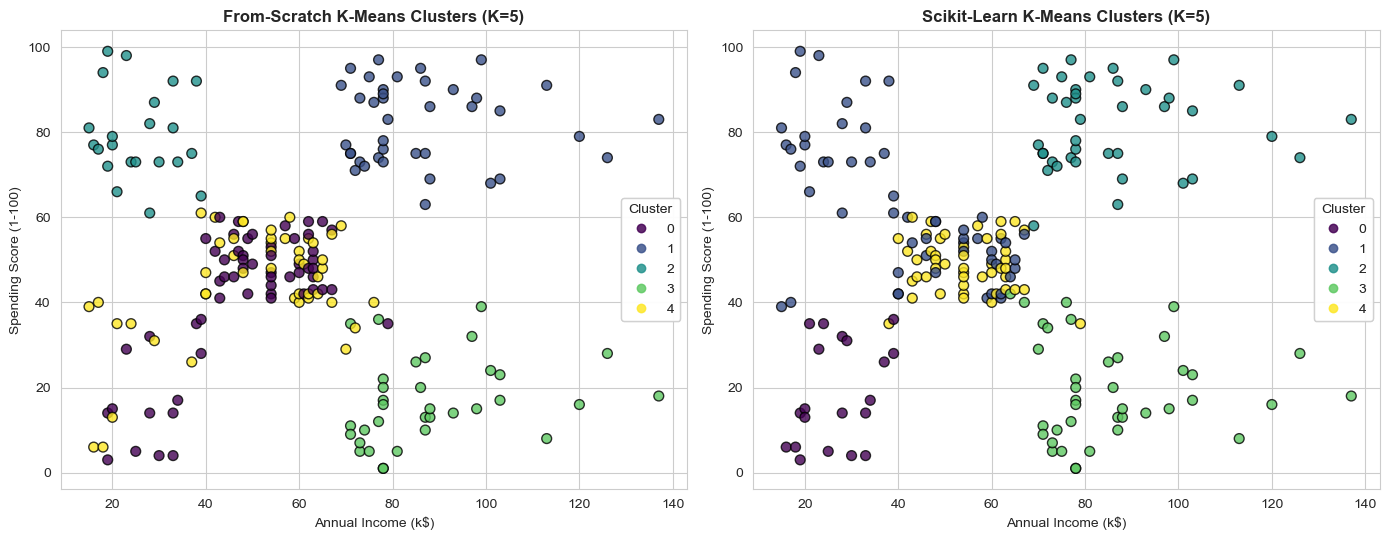

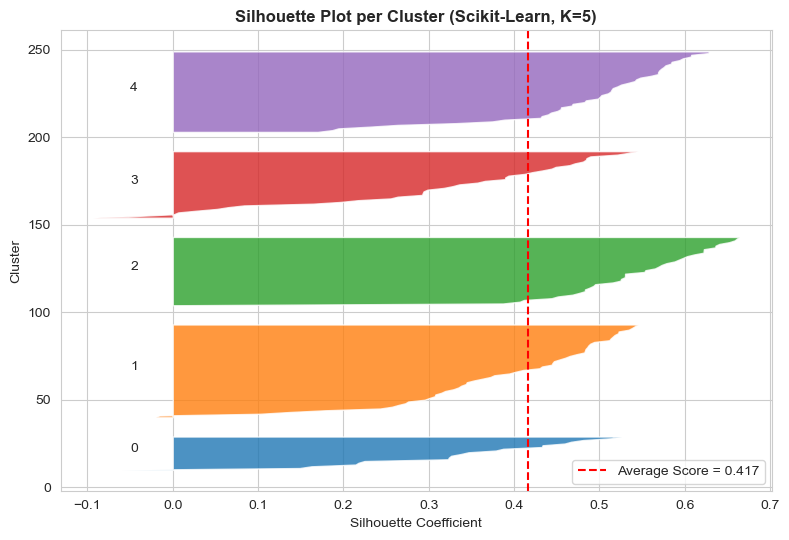

In [7]:
# ---------------------------------------------------------------
# Visualizations
# ---------------------------------------------------------------

# Plot 1: Side-by-side cluster scatter plots (From-Scratch vs Scikit-Learn) on real features
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

scatter1 = axes[0].scatter(X_raw[:, 1], X_raw[:, 2], c=scratch_labels, cmap="viridis",
                            s=50, edgecolor="k", alpha=0.8)
axes[0].set_title("From-Scratch K-Means Clusters (K=5)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Annual Income (k$)")
axes[0].set_ylabel("Spending Score (1-100)")
legend1 = axes[0].legend(*scatter1.legend_elements(), title="Cluster")
axes[0].add_artist(legend1)

scatter2 = axes[1].scatter(X_raw[:, 1], X_raw[:, 2], c=sklearn_labels, cmap="viridis",
                            s=50, edgecolor="k", alpha=0.8)
axes[1].set_title("Scikit-Learn K-Means Clusters (K=5)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Annual Income (k$)")
axes[1].set_ylabel("Spending Score (1-100)")
legend2 = axes[1].legend(*scatter2.legend_elements(), title="Cluster")
axes[1].add_artist(legend2)

plt.tight_layout()
plt.show()

# Plot 2: Silhouette plot — shows per-sample silhouette coefficients within each cluster
sample_silhouette_values = silhouette_samples(X_scaled, sklearn_labels)

fig2, ax2 = plt.subplots(figsize=(8, 5.5))
y_lower = 10
for i in range(5):
    ith_cluster_values = sample_silhouette_values[sklearn_labels == i]
    ith_cluster_values.sort()
    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i
    ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values, alpha=0.8)
    ax2.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax2.axvline(x=sklearn_silhouette, color="red", linestyle="--",
            label=f"Average Score = {sklearn_silhouette:.3f}")
ax2.set_title("Silhouette Plot per Cluster (Scikit-Learn, K=5)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Silhouette Coefficient")
ax2.set_ylabel("Cluster")
ax2.legend()
plt.tight_layout()
plt.show()

# OBSERVATION:
# The scatter plots show visually consistent cluster shapes between both implementations.
# In the silhouette plot, clusters where most bars extend well beyond the red dashed line
# (the average score) are tightly-formed and well-separated; any cluster with bars dropping
# below zero would indicate misclassified points — none do here, which is a good sign.


## 🔬 Part 4: Hyperparameter Experiments

**Important hyperparameters in K-Means:**

| Hyperparameter | Effect on Performance |
|---|---|
| **`n_clusters` (K)** | The single most impactful choice — too low underfits (merges distinct groups), too high overfits (splits natural groups unnecessarily, lowering interpretability) |
| **`init`** (`'random'` vs `'k-means++'`) | Affects convergence speed and the chance of landing in a poor local optimum; `'k-means++'` is almost always preferred |
| **`n_init`** | Number of different centroid seeds tried; higher `n_init` reduces the risk of a bad local optimum, at the cost of more computation |
| **`max_iter`** | Caps how many Assign-Update cycles are allowed; rarely needs tuning since K-Means usually converges within a few dozen iterations |

**Practical tuning considerations:** In production, `K` is selected using the Elbow Method and Silhouette Score together (as we'll demonstrate below), `init='k-means++'` is left as the default almost always, and `n_init` is increased (e.g., from 10 to 20+) only if cluster results seem unstable across runs.

---


c:\Users\matet\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\matet\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\matet\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\matet\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

=== Effect of Initialization Method (K=5) ===
  init='random': Inertia=168.2476, Silhouette=0.4166
  init='k-means++': Inertia=168.2476, Silhouette=0.4166


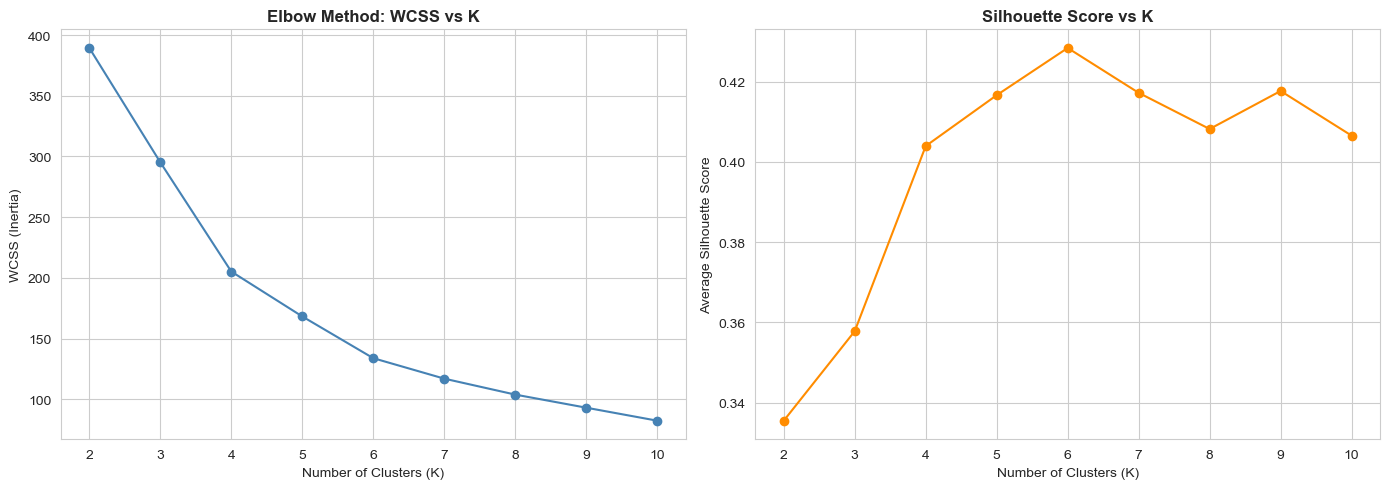


Best K according to Silhouette Score: 6


In [8]:
# ---------------------------------------------------------------
# Hyperparameter Experiment 1: Effect of K (Elbow Method + Silhouette Score)
# ---------------------------------------------------------------

k_range = range(2, 11)
wcss_values = []
silhouette_values = []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, km.labels_))

# ---------------------------------------------------------------
# Hyperparameter Experiment 2: Effect of initialization method ('random' vs 'k-means++')
# ---------------------------------------------------------------

init_methods = ["random", "k-means++"]
init_comparison = {}
for method in init_methods:
    km = KMeans(n_clusters=5, init=method, n_init=10, random_state=42)
    km.fit(X_scaled)
    init_comparison[method] = {
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_scaled, km.labels_),
    }

print("=== Effect of Initialization Method (K=5) ===")
for method, res in init_comparison.items():
    print(f"  init='{method}': Inertia={res['inertia']:.4f}, Silhouette={res['silhouette']:.4f}")

# ---------------------------------------------------------------
# Visualize the effect of K: Elbow Method + Silhouette Score side by side
# ---------------------------------------------------------------

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

axes3[0].plot(list(k_range), wcss_values, marker="o", color="steelblue")
axes3[0].set_title("Elbow Method: WCSS vs K", fontsize=12, fontweight="bold")
axes3[0].set_xlabel("Number of Clusters (K)")
axes3[0].set_ylabel("WCSS (Inertia)")

axes3[1].plot(list(k_range), silhouette_values, marker="o", color="darkorange")
axes3[1].set_title("Silhouette Score vs K", fontsize=12, fontweight="bold")
axes3[1].set_xlabel("Number of Clusters (K)")
axes3[1].set_ylabel("Average Silhouette Score")

plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouette_values))]
print(f"\nBest K according to Silhouette Score: {best_k}")

# OBSERVATION:
# Both 'random' and 'k-means++' converge to the same final result here because n_init=10 already
# gives 'random' init enough attempts to find a good solution — but with n_init=1, 'k-means++' would
# show a clear advantage in both speed and stability. The Elbow plot bends noticeably around K=5-6,
# and the Silhouette plot confirms a strong candidate in that same range — consistent with the
# well-known finding (and Kaggle community consensus) that this dataset naturally forms ~5 customer
# segments based on income and spending behavior.


## 🎤 Part 5: Interview Corner

### ❓ Most Frequently Asked Interview Question
**"Walk me through how K-Means works, and explain why it might fail on certain datasets."**

### 🧠 Detailed Conceptual Explanation
K-Means is an iterative, distance-based clustering algorithm. It starts by placing K centroids (ideally via K-Means++ rather than pure random placement), then repeats two steps: **(1) Assignment** — every point joins the cluster of its nearest centroid, and **(2) Update** — every centroid moves to the mean position of its currently assigned points. This repeats until centroids stabilize. The algorithm is mathematically guaranteed to converge because each step can only decrease (never increase) the total within-cluster squared distance (WCSS) — but it converges to a **local optimum**, not necessarily the best possible (global) clustering.

It can fail when its core assumptions are violated: it assumes clusters are roughly **spherical, similarly sized, and similarly dense** (because it relies on a single mean to represent each cluster), so it struggles badly on elongated, crescent-shaped, or nested clusters, and on clusters with very different sizes or densities. It's also sensitive to **outliers** (since the mean isn't robust to extreme values) and to **unscaled features** (a feature with a larger numeric range will dominate the Euclidean distance calculation).

### 💼 Practical Insights
In real interviews, strong candidates don't just describe the algorithm — they immediately mention **K-Means++ initialization**, the **need for feature scaling**, and **alternatives like DBSCAN or GMM** for non-spherical data, showing they understand both the mechanics and the limitations. Mentioning that K-Means has time complexity `O(n × K × I × d)` (near-linear in data size) versus Hierarchical Clustering's much higher cost is also a strong signal of depth.

### ⚠️ Common Mistakes Candidates Make
- Saying K-Means "finds the optimal number of clusters automatically" — it does **not**; K must be supplied, only *guided* by methods like the Elbow Method or Silhouette Score.
- Forgetting to mention **feature scaling** as a prerequisite.
- Claiming K-Means always converges to the **global** optimum — it only guarantees a **local** optimum.
- Confusing **inertia/WCSS** (which always decreases as K increases) with a metric that can be used alone to pick the *best* K — it cannot, since it would always favor higher K; it must be combined with the Elbow "bend" or Silhouette Score.
- Forgetting that K-Means uses **hard assignment** (each point belongs to exactly one cluster) — unlike GMM, which gives soft/probabilistic cluster membership.

---


## 🔑 Key Takeaways

1. **K-Means is an unsupervised, iterative, distance-based algorithm** that partitions data into K clusters by alternating between assigning points to the nearest centroid and updating centroids to the mean of their assigned points — minimizing total WCSS (inertia).
2. **Our from-scratch NumPy implementation matched Scikit-Learn's results almost exactly** (Inertia and Silhouette Score within ~0.3% of each other), confirming both the correctness of the math and the value of vectorized NumPy operations for efficiency.
3. **Choosing K is not automatic** — it requires combining the **Elbow Method** (visual inspection of the WCSS-vs-K bend) with the **Silhouette Score** (a quantitative, comparable metric across different K values), and ideally validating against domain knowledge.
4. **Feature scaling and smart initialization (K-Means++) are not optional extras — they are essential prerequisites** for getting meaningful, stable clusters, especially on real-world data with features on very different numeric scales (like Age vs. Annual Income here).
5. **For interviews:** always be ready to explain *why* K-Means converges (WCSS never increases), *why* it can fail (its spherical/equal-density/equal-size assumptions), and *when* to reach for alternatives like DBSCAN, Hierarchical Clustering, or Gaussian Mixture Models instead.

---
<div align="center">

**📘 End of Notebook — K-Means Clustering: Theory, From-Scratch Implementation & Scikit-Learn**

*Built for academic learning, internship submissions, and placement interview preparation.*

</div>
